# Brain Age: Leave-One-Site-Out Cross Validation
Questo notebook esegue un addestramento partendo da zero e convalida il modello utilizzando una **Cross-Validation basata sui siti clinici (Guys, HH, IOP)**. 
Non c'è un Test Set isolato: le prestazioni del modello vengono valutate misurando quanto è bravo a generalizzare su un *intero ospedale/scanner* (Validation Set) dopo essersi addestrato sugli altri due ospedali.

In [1]:
!rm -rf SFCN
!git clone https://github.com/PietroSchgor/SFCN.git

import sys
import os
sys.path.append(os.path.abspath('./SFCN'))

Cloning into 'SFCN'...
remote: Enumerating objects: 396, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 396 (delta 8), reused 8 (delta 8), pack-reused 379 (from 3)
Receiving objects: 100% (396/396), 146.78 MiB | 41.00 MiB/s, done.
Resolving deltas: 100% (190/190), done.


In [2]:
import os
import pandas as pd
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datetime import datetime
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr

from dp_model.model_files.sfcn import SFCN
from dp_model import dp_utils as dpu

MODELS_DIR = '/kaggle/working/models'
PLOTS_DIR = '/kaggle/working/plots'
os.makedirs(MODELS_DIR, exist_ok=True)

os.makedirs(PLOTS_DIR, exist_ok=True)

## 1. Configurazione

In [3]:
# --- PERCORSI DATI ---
CSV_PATH = "/kaggle/input/datasets/collab4444/ixi-info/ixi_info.csv"
DATA_DIR = "/kaggle/input/datasets/collab4444/dataset-2-t1-t2/Prep_IXI_T2/Prep_IXI" # Cartella root che contiene Prep_Guys, Prep_HH, Prep_IOP

CORRECTED_DIR = ""
CORRECTED_GEN_DIR = "/kaggle/input/datasets/collab11111/ixi-t2-t1-corrected/results" # <-- Aggiorna col path di Kaggle se necessario!
MODALITY_SUFFIX = "" # Oppure "_T1" o "_T2" a seconda dei nomi delle tue cartelle

# --- MODALITÀ DI ADDESTRAMENTO (TOGGLE REALE / GENERATO / MISTO) ---
# Scegli la composizione del training set:
# - "MIXED"     : ALLENA SIA SU DATI REALI CHE GENERATI (Data Augmentation Ibrida, raddoppia il dataset)
# - "GEN_ONLY"  : Allena SOLO sui dati generati
# - "REAL_ONLY" : Allena SOLO sui dati reali (baseline convenzionale)
TRAINING_MODE = "MIXED"

GENERATION_MODEL = "Pix2Pix" # Es. "EAGAN", "Pix2Pix", "PTNEt3D"
GEN_DATA_DIR = "/kaggle/input/datasets/collab2000/risultati-dataset-2/dataset 2/T1 - T2/T2 to T1"

# --- SELEZIONE SITI E VALUTAZIONE MODELLI ---
ALL_SITES = ['Guys', 'HH', 'IOP']

# Siti da addestrare (Leave-One-Site-Out Cross Validation):
# - Per addestrare tutti i 3 siti: SITES_TO_TRAIN = ['Guys', 'HH', 'IOP']
# - Per addestrare SOLO un sito specifico: es. SITES_TO_TRAIN = ['Guys'] (allena su HH+IOP, valida su Guys)
#   I siti NON inclusi in SITES_TO_TRAIN verranno valutati caricando il modello pre-addestrato (se presente).
# - Per NON addestrare nulla ed eseguire SOLO la valutazione dei modelli salvati: SITES_TO_TRAIN = []
SITES_TO_TRAIN = [ '']

# Cartella dei modelli pre-addestrati da caricare per la valutazione (.pth)
# - Lascia vuoto ("") per cercarli nella cartella locale MODELS_DIR ('/kaggle/working/models')
# - Oppure imposta il percorso Kaggle (es. '/kaggle/input/tuo-dataset-modelli/models')
PRETRAINED_MODELS_DIR = "/kaggle/working/SFCN/results age IXI/results T1/gen + real/pix2pix"

# --- IPERPARAMETRI ---
EPOCHS = 200
BATCH_SIZE = 8
LR = 1e-4
WEIGHT_DECAY = 1e-3
PATIENCE = 30

# --- CALCOLO DINAMICO DEL RANGE DI ETÀ ---
import math

df_temp = pd.read_csv(CSV_PATH)
reference_date_temp = datetime(2015, 2, 23)
ages_temp = []
for idx, row in df_temp.iterrows():
    dob_str = row['DOB']
    if pd.isna(dob_str): continue
    try:
        dob = datetime.strptime(str(dob_str).split(" ")[0], "%Y-%m-%d")
        ages_temp.append((reference_date_temp - dob).days / 365.25)
    except:
        pass

MIN_AGE = math.floor(min(ages_temp))
MAX_AGE = math.ceil(max(ages_temp))
OUTPUT_DIM = MAX_AGE - MIN_AGE
BIN_RANGE = [MIN_AGE, MAX_AGE]

print(f"Calculated ages from dataset: Min {min(ages_temp):.2f}, Max {max(ages_temp):.2f}")
print(f"Bin Adaptation (SFCN paper style): Range {BIN_RANGE}, Output Dimension (N. Bins) = {OUTPUT_DIM}")


Calculated ages from dataset: Min 28.64, Max 94.90
Bin Adaptation (SFCN paper style): Range [28, 95], Output Dimension (N. Bins) = 67


## 2. Site-Aware Dataloader
Il Dataloader carica solo i pazienti provenienti dai siti specificati nella lista `allowed_sites`.

In [4]:
import os
import re
import glob

def find_generated_site_folder(gen_data_dir, site, gen_model):
    """
    Trova la cartella contenente le immagini generate per un determinato sito e modello,
    gestendo:
    - Differenze di maiuscole/minuscole (es. PREP_GUYS vs Prep_Guys vs Guys)
    - Suffissi come ' (1)' (es. Predizioni_PTNEt3D (1))
    - Varianti nel nome modello (es. ptnet, ptnet3d, Predizioni_PTNet, Predizioni_PTNet3D)
    - Gerarchia invertita (GEN_DATA_DIR / modello / sito) o immagini direttamente nel sito
    """
    if not gen_data_dir or not os.path.exists(gen_data_dir):
        return None
        
    site_lower = site.lower()
    model_clean = re.sub(r'[^a-zA-Z0-9]', '', gen_model.lower())
    
    # Token chiave per ciascun modello
    if 'ptnet' in model_clean:
        model_tokens = ['ptnet3d', 'ptnet']
    elif 'eagan' in model_clean:
        model_tokens = ['eagan']
    elif 'pix2pix' in model_clean:
        model_tokens = ['pix2pix', 'p2p']
    else:
        model_tokens = [model_clean]
        
    # Pattern 1: gen_data_dir / [cartella_sito] / [cartella_modello]
    candidate_site_dirs = []
    try:
      for entry in os.listdir(gen_data_dir):
        entry_path = os.path.join(gen_data_dir, entry)
        if os.path.isdir(entry_path) and site_lower in entry.lower():
          candidate_site_dirs.append(entry_path)
    except Exception:
      pass
      
    for s_dir in candidate_site_dirs:
      # 1a. Cerca sotto-cartella del modello dentro s_dir
      try:
        sub_entries = os.listdir(s_dir)
        for sub in sub_entries:
          sub_path = os.path.join(s_dir, sub)
          if os.path.isdir(sub_path):
            clean_sub = re.sub(r'[^a-zA-Z0-9]', '', sub.lower())
            if any(tok in clean_sub for tok in model_tokens):
              nii_files = [f for f in os.listdir(sub_path) if f.endswith('.nii')]
              if nii_files:
                return sub_path
      except Exception:
        pass
        
      # 1b. File .nii direttamente nella cartella del sito
      try:
        nii_files = [f for f in os.listdir(s_dir) if f.startswith('registered_image_') and f.endswith('.nii')]
        if nii_files:
          return s_dir
      except Exception:
        pass

    # Pattern 2: gen_data_dir / [cartella_modello] / [cartella_sito]
    try:
      for entry in os.listdir(gen_data_dir):
        entry_path = os.path.join(gen_data_dir, entry)
        if os.path.isdir(entry_path):
          clean_entry = re.sub(r'[^a-zA-Z0-9]', '', entry.lower())
          if any(tok in clean_entry for tok in model_tokens):
            for sub in os.listdir(entry_path):
              sub_path = os.path.join(entry_path, sub)
              if os.path.isdir(sub_path) and site_lower in sub.lower():
                nii_files = [f for f in os.listdir(sub_path) if f.endswith('.nii')]
                if nii_files:
                  return sub_path
    except Exception:
      pass

    # Diagnostica in caso di fallimento
    print(f"Warning: Generated images folder for model '{gen_model}' in site '{site}' not found inside '{gen_data_dir}'")
    if os.path.exists(gen_data_dir):
      try:
        all_dirs = [d for d in os.listdir(gen_data_dir) if os.path.isdir(os.path.join(gen_data_dir, d))]
        print(f"  --> Cartelle presenti in GEN_DATA_DIR: {all_dirs}")
        for s_dir in candidate_site_dirs:
          subs = [d for d in os.listdir(s_dir) if os.path.isdir(os.path.join(s_dir, d))]
          print(f"  --> Sotto-cartelle trovate in '{os.path.basename(s_dir)}': {subs}")
      except Exception:
        pass
    return None

class IXISiteDataset(Dataset):
    def __init__(self, data_dir, csv_path, allowed_sites, is_train=False):
        self.samples = []
        self.is_train = is_train
        self.bin_range = BIN_RANGE
        self.bin_step = 1
        self.sigma = 1.0
        
        df = pd.read_csv(csv_path)
        reference_date = datetime(2015, 2, 23)
        
        # Gestione dinamica modalita': "MIXED", "REAL_ONLY", "GEN_ONLY"
        train_mode = globals().get('TRAINING_MODE', 'MIXED').upper()
        if 'USE_GENERATED_FOR_TRAIN' in globals() and 'TRAINING_MODE' not in globals():
            train_mode = "GEN_ONLY" if globals()['USE_GENERATED_FOR_TRAIN'] else "REAL_ONLY"
            
        for site in allowed_sites:
            folder_paths = []
            
            # 1. Immagini Reali (In Validation SEMPRE; in Train solo se REAL_ONLY o MIXED)
            if not self.is_train or train_mode in ["REAL_ONLY", "MIXED"]:
                folder_name = f"Prep_{site}{MODALITY_SUFFIX}"
                folder_path_real = os.path.join(data_dir, folder_name)
                if not os.path.exists(folder_path_real):
                    folder_path_real = os.path.join(data_dir, f"Prep_{site}")
                    
                if os.path.exists(folder_path_real):
                    folder_paths.append((folder_path_real, False))
                else:
                    print(f"Warning: Real folder for site {site} not found at {folder_path_real}")
                    
            # 2. Immagini Generate (Solo in Train se GEN_ONLY o MIXED)
            if self.is_train and train_mode in ["GEN_ONLY", "MIXED"]:
                folder_path_gen = find_generated_site_folder(GEN_DATA_DIR, site, GENERATION_MODEL)
                if folder_path_gen is not None and os.path.exists(folder_path_gen):
                    folder_paths.append((folder_path_gen, True))
            
            # Itera su tutti i percorsi (reali e, se in train/mixed, anche generati)
            for folder_path, is_generated in folder_paths:
                if not os.path.exists(folder_path):
                    continue
                    
                for file in os.listdir(folder_path):
                    if not (file.startswith("registered_image_") and file.endswith(".nii")):
                        continue
                        
                    nii_path = os.path.join(folder_path, file)
                    
                    # Sostituzione file corrotto per immagini reali
                    if not is_generated:
                        if CORRECTED_DIR:
                            corrected_path = os.path.join(CORRECTED_DIR, site, file)
                            if os.path.exists(corrected_path):
                                nii_path = corrected_path
                    else:
                        # Sostituzione file corrotto per immagini generate
                        if CORRECTED_GEN_DIR:
                            corrected_gen_path_site = os.path.join(CORRECTED_GEN_DIR, site, file)
                            corrected_gen_path_direct = os.path.join(CORRECTED_GEN_DIR, file)
                            if os.path.exists(corrected_gen_path_site):
                                nii_path = corrected_gen_path_site
                            elif os.path.exists(corrected_gen_path_direct):
                                nii_path = corrected_gen_path_direct
                        
                    # Regex flessibile per estrarre l'ID paziente
                    match = re.search(r'registered_image_(\d+)', file)
                    if not match:
                        continue
                    ixi_id_str = match.group(1)
                    
                    try:
                        ixi_id = int(ixi_id_str)
                    except ValueError:
                        continue
                        
                    row = df[df['IXI_ID'] == ixi_id]
                    if len(row) == 0:
                        continue
                        
                    dob_str = row.iloc[0]['DOB']
                    if pd.isna(dob_str):
                        continue
                        
                    try:
                        dob_str = str(dob_str).split(" ")[0]
                        dob = datetime.strptime(dob_str, "%Y-%m-%d")
                        true_age = (reference_date - dob).days / 365.25
                        
                        y, _ = dpu.num2vect(true_age, self.bin_range, self.bin_step, self.sigma)
                        
                        self.samples.append({
                            "ixi_id": ixi_id,
                            "site": site,
                            "nii_path": nii_path,
                            "label_vect": y,
                            "true_age": true_age,
                            "is_generated": is_generated
                        })
                    except Exception:
                        continue
                        
        if self.is_train:
            n_real = sum(1 for s in self.samples if not s['is_generated'])
            n_gen = sum(1 for s in self.samples if s['is_generated'])
            print(f"[TRAIN ({train_mode})] Caricati {len(self.samples)} pazienti totali ({n_real} Reali + {n_gen} Generati) sui siti: {allowed_sites}.")
        else:
            print(f"[VAL (REAL)] Caricati {len(self.samples)} pazienti Reali sul sito: {allowed_sites}.")

    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = nib.load(sample['nii_path'])
        data = img.get_fdata(dtype=np.float32)
        
        # Gestione NaNs
        if np.isnan(data).any():
            data = np.nan_to_num(data)
            
        mean_val = np.mean(data)
        if mean_val > 0:
            data = data / mean_val
            
        in_sp = data.shape
        out_sp = (160, 192, 160)
        
        if self.is_train:
            dx = np.random.randint(-3, 4)
            dy = np.random.randint(-3, 4)
            dz = np.random.randint(-3, 4)
            # Data augmentation: Random horizontal flip
            if np.random.rand() > 0.5:
                data = np.flip(data, axis=0).copy()
        else:
            dx, dy, dz = 0, 0, 0
            
        x_c = int((in_sp[0] - out_sp[0]) / 2) + dx
        y_c = int((in_sp[1] - out_sp[1]) / 2) + dy
        z_c = int((in_sp[2] - out_sp[2]) / 2) + dz
        
        data = data[x_c:x_c+out_sp[0], y_c:y_c+out_sp[1], z_c:z_c+out_sp[2]]
        data = np.expand_dims(data, axis=0)
        
        tensor_data = torch.from_numpy(data)
        label_vect = torch.tensor(sample['label_vect'], dtype=torch.float32)
        return tensor_data, label_vect, float(sample['true_age'])


## 3. Training Loop (Leave-One-Site-Out)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import glob

def evaluate_site_model(val_site, model_path):
    print(f"\n{'='*50}")
    print(f" VALUTAZIONE MODELLO PRE-ADDESTRATO SUL SITO: [{val_site}]")
    print(f" PATH: {model_path}")
    print(f"{'='*50}")
    
    val_dataset = IXISiteDataset(DATA_DIR, CSV_PATH, [val_site], is_train=False)
    if len(val_dataset) == 0:
        print(f"Dataset di validazione vuoto per {val_site}. Salto.")
        return None, None, None, None
        
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    model = SFCN(output_dim=OUTPUT_DIM)
    state_dict = torch.load(model_path, map_location=device)
    # Rimuovi prefisso module. se salvato con DataParallel
    clean_state_dict = {k[7:] if k.startswith('module.') else k: v for k, v in state_dict.items()}
    model.load_state_dict(clean_state_dict)
    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model = model.to(device)
    model.eval()
    
    bin_centers = np.arange(BIN_RANGE[0], BIN_RANGE[1], 1)
    final_preds = []
    final_trues = []
    
    with torch.no_grad():
        for inputs, label_vect, true_age in val_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)[0].reshape(inputs.size(0), -1)
            probs = torch.exp(outputs).cpu().numpy()
            final_preds.extend(np.dot(probs, bin_centers))
            final_trues.extend(true_age.numpy())
            
    val_mae = np.mean(np.abs(np.array(final_trues) - np.array(final_preds)))
    print(f"Modello caricato valutato su {val_site} -> Validation MAE: {val_mae:.2f} anni")
    return val_mae, np.array(final_trues), np.array(final_preds), val_site

def train_site_model(train_sites, val_site):
    print(f"\n{'='*50}")
    print(f" FOLD: Testing on site [{val_site}]")
    print(f" Training on: {train_sites}")
    print(f"{'='*50}")
    
    train_dataset = IXISiteDataset(DATA_DIR, CSV_PATH, train_sites, is_train=True)
    val_dataset = IXISiteDataset(DATA_DIR, CSV_PATH, [val_site], is_train=False)
    
    if len(train_dataset) == 0 or len(val_dataset) == 0:
        print("Empty dataset. Skipping fold.")
        return None, None, None, None
        
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inizializziamo DA ZERO (Nessun pretraining caricato)
    model = SFCN(output_dim=OUTPUT_DIM)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.KLDivLoss(reduction='batchmean')
    
    best_val_mae = float('inf')
    epochs_no_improve = 0
    best_model_path = os.path.join(MODELS_DIR, f'best_model_val_{val_site}.pth')
    
    bin_centers = np.arange(BIN_RANGE[0], BIN_RANGE[1], 1)
    
    # Tracciamento storico per epoca
    train_loss_history = []
    val_loss_history = []
    val_mae_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        
        for inputs, label_vect, true_age in train_loader:
            inputs, label_vect = inputs.to(device), label_vect.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)[0].reshape(inputs.size(0), -1)
            
            loss = criterion(outputs, label_vect)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        fold_val_preds = []
        fold_val_trues = []
        
        with torch.no_grad():
            for inputs, label_vect, true_age in val_loader:
                inputs, label_vect = inputs.to(device), label_vect.to(device)
                outputs = model(inputs)[0].reshape(inputs.size(0), -1)
                
                loss = criterion(outputs, label_vect)
                val_loss += loss.item() * inputs.size(0)
                
                probs = torch.exp(outputs).cpu().numpy()
                preds = np.dot(probs, bin_centers)
                
                fold_val_preds.extend(preds)
                fold_val_trues.extend(true_age.numpy())
                
        val_loss /= len(val_loader.dataset)
        val_mae = np.mean(np.abs(np.array(fold_val_trues) - np.array(fold_val_preds)))
        
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        val_mae_history.append(val_mae)
        
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.2f}")
        
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            epochs_no_improve = 0
            if isinstance(model, nn.DataParallel):
                torch.save(model.module.state_dict(), best_model_path)
            else:
                torch.save(model.state_dict(), best_model_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1} (Pazienza massima raggiunta: {PATIENCE})")
                break
                
    print(f"Best Val MAE for {val_site}: {best_val_mae:.2f} years")
    
    # --- PLOT DELLE CURVE DI APPRENDIMENTO PER EPOCA ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(train_loss_history) + 1)
    
    # Subplot 1: Train Loss vs Val Loss
    ax1.plot(epochs_range, train_loss_history, label='Train Loss (KLDiv)', color='royalblue', linewidth=2)
    ax1.plot(epochs_range, val_loss_history, label='Val Loss (KLDiv)', color='darkorange', linewidth=2)
    ax1.set_xlabel('Epoca', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'Curve di Loss - Test Site: {val_site}', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Subplot 2: Val MAE per epoca
    ax2.plot(epochs_range, val_mae_history, label='Val MAE (Anni)', color='crimson', linewidth=2)
    ax2.axhline(y=best_val_mae, color='forestgreen', linestyle='--', label=f'Miglior Val MAE: {best_val_mae:.2f}y')
    ax2.set_xlabel('Epoca', fontsize=12)
    ax2.set_ylabel('MAE (Anni)', fontsize=12)
    ax2.set_title(f'Andamento Val MAE per Epoca - Test Site: {val_site}', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    curve_save_path = os.path.join(PLOTS_DIR, f'training_curves_val_{val_site}.png')
    plt.savefig(curve_save_path, dpi=300)
    plt.show()
    
    # Ricarica e valuta il miglior modello per estrarre le predizioni definitive
    best_model = SFCN(output_dim=OUTPUT_DIM)
    state_dict = torch.load(best_model_path, map_location=device)
    clean_state_dict = {k[7:] if k.startswith('module.') else k: v for k, v in state_dict.items()}
    best_model.load_state_dict(clean_state_dict)
    if torch.cuda.device_count() > 1:
        best_model = nn.DataParallel(best_model)
    best_model = best_model.to(device)
    best_model.eval()
    
    final_preds = []
    final_trues = []
    with torch.no_grad():
        for inputs, label_vect, true_age in val_loader:
            inputs = inputs.to(device)
            outputs = best_model(inputs)[0].reshape(inputs.size(0), -1)
            probs = torch.exp(outputs).cpu().numpy()
            final_preds.extend(np.dot(probs, bin_centers))
            final_trues.extend(true_age.numpy())
            
    return best_val_mae, np.array(final_trues), np.array(final_preds), val_site

def find_site_model_path(val_site, pretrained_dir, local_dir):
    patterns = [
        f'best_model_val_{val_site}.pth',
        f'model_val_{val_site}.pth',
        f'*val_{val_site}*.pth',
        f'*{val_site}*.pth'
    ]
    search_dirs = []
    if pretrained_dir and os.path.exists(pretrained_dir):
        search_dirs.append(pretrained_dir)
    if local_dir and os.path.exists(local_dir):
        search_dirs.append(local_dir)
        
    for s_dir in search_dirs:
        for pat in patterns:
            matches = glob.glob(os.path.join(s_dir, pat))
            if matches:
                return matches[0]
    return None

# --- ESECUZIONE DELLA CROSS VALIDATION ---
site_results = []
all_trues = []
all_preds = []
all_site_labels = []

for val_site in ALL_SITES:
    if val_site in SITES_TO_TRAIN:
        train_sites = [s for s in ALL_SITES if s != val_site]
        mae, t_trues, t_preds, site_name = train_site_model(train_sites, val_site)
    else:
        target_model_path = find_site_model_path(val_site, PRETRAINED_MODELS_DIR, MODELS_DIR)
        if target_model_path:
            mae, t_trues, t_preds, site_name = evaluate_site_model(val_site, model_path=target_model_path)
        else:
            print(f"\n[!] ATTENZIONE: Modello per {val_site} non trovato in '{PRETRAINED_MODELS_DIR}' o '{MODELS_DIR}' e sito non presente in SITES_TO_TRAIN. Salto.")
            mae = None
            
    if mae is not None:
        site_results.append((val_site, mae))
        all_trues.extend(t_trues)
        all_preds.extend(t_preds)
        all_site_labels.extend([site_name]*len(t_trues))



 VALUTAZIONE MODELLO PRE-ADDESTRATO SUL SITO: [Guys]
 PATH: /kaggle/working/SFCN/results age IXI/results T1/gen + real/pix2pix/best_model_val_Guys.pth
[VAL (REAL)] Caricati 304 pazienti Reali sul sito: ['Guys'].
Modello caricato valutato su Guys -> Validation MAE: 5.75 anni

 VALUTAZIONE MODELLO PRE-ADDESTRATO SUL SITO: [HH]
 PATH: /kaggle/working/SFCN/results age IXI/results T1/gen + real/pix2pix/best_model_val_HH.pth
[VAL (REAL)] Caricati 177 pazienti Reali sul sito: ['HH'].
Modello caricato valutato su HH -> Validation MAE: 5.34 anni

 VALUTAZIONE MODELLO PRE-ADDESTRATO SUL SITO: [IOP]
 PATH: /kaggle/working/SFCN/results age IXI/results T1/gen + real/pix2pix/best_model_val_IOP.pth
[VAL (REAL)] Caricati 68 pazienti Reali sul sito: ['IOP'].
Modello caricato valutato su IOP -> Validation MAE: 6.24 anni


## 4. Risultati Globali di Validazione (Senza Bias Correction)


 LEAVE-ONE-SITE-OUT CROSS VALIDATION SUMMARY
Site Guys -> Validation MAE: 5.75 years
Site HH   -> Validation MAE: 5.34 years
Site IOP  -> Validation MAE: 6.24 years

GLOBAL (Mean across all sites) -> MAE: 5.68 years | Pearson r: 0.912


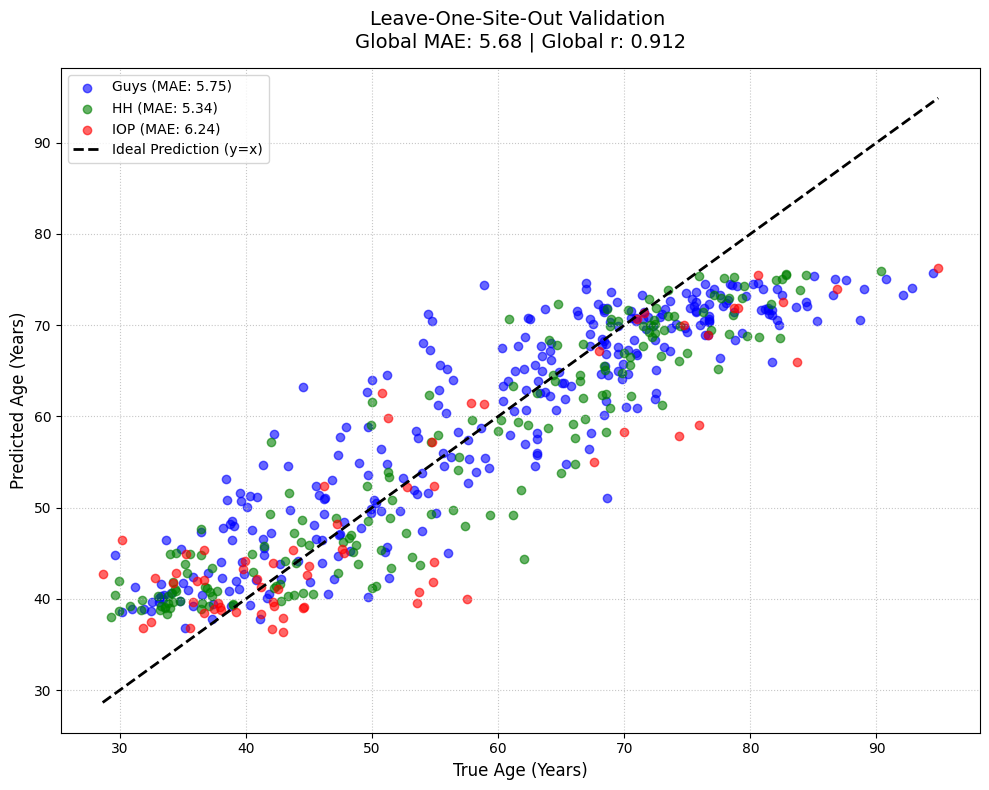


Full results saved to: /kaggle/working/plots/ixi_cross_validation_predictions.csv


In [6]:
if len(site_results) > 0:
    print("\n==============================================")
    print(" LEAVE-ONE-SITE-OUT CROSS VALIDATION SUMMARY")
    print("==============================================")
    for site, mae in site_results:
        print(f"Site {site:4s} -> Validation MAE: {mae:.2f} years")
        
    global_mae = np.mean(np.abs(np.array(all_trues) - np.array(all_preds)))
    global_corr, _ = pearsonr(all_trues, all_preds)
    print(f"\nGLOBAL (Mean across all sites) -> MAE: {global_mae:.2f} years | Pearson r: {global_corr:.3f}")
    
    # --- PLOT RISULTATI ---
    plt.figure(figsize=(10, 8))
    
    colors = {'Guys': 'blue', 'HH': 'green', 'IOP': 'red'}
    
    for site in ALL_SITES:
        # Filtriamo i pazienti di questo sito
        site_trues = [all_trues[i] for i in range(len(all_site_labels)) if all_site_labels[i] == site]
        site_preds = [all_preds[i] for i in range(len(all_site_labels)) if all_site_labels[i] == site]
        
        if len(site_trues) > 0:
            site_mae = np.mean(np.abs(np.array(site_trues) - np.array(site_preds)))
            plt.scatter(site_trues, site_preds, alpha=0.6, color=colors.get(site, 'black'), label=f"{site} (MAE: {site_mae:.2f})")
            
    # Linea ideale y=x
    min_age = min(all_trues)
    max_age = max(all_trues)
    plt.plot([min_age, max_age], [min_age, max_age], 'k--', lw=2, label='Ideal Prediction (y=x)')
    
    plt.title(f"Leave-One-Site-Out Validation \nGlobal MAE: {global_mae:.2f} | Global r: {global_corr:.3f}", fontsize=14, pad=15)
    plt.xlabel("True Age (Years)", fontsize=12)
    plt.ylabel("Predicted Age (Years)", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'site_cross_validation_results.png'), dpi=300)
    plt.show()
    
    # --- SALVATAGGIO IN CSV ---
    df_results = pd.DataFrame({
        'Site': all_site_labels,
        'True_Age': all_trues,
        'Predicted_Age': all_preds,
        'Absolute_Error': np.abs(np.array(all_trues) - np.array(all_preds))
    })
    
    csv_out_path = os.path.join(PLOTS_DIR, 'ixi_cross_validation_predictions.csv')
    df_results.to_csv(csv_out_path, index=False)
    print(f"\nFull results saved to: {csv_out_path}")
else:

    print("No results to plot.")